# DATA 266 - Lab 1 | Part 1: Building a GPT-style LLM from Scratch

In [1]:
!pip install datasets matplotlib torch --quiet

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt
import math
import random
import numpy as np
import os
import shutil

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1.1 Data Preprocessing

In [23]:
seq_length = 128

dataset = load_dataset('roneneldan/TinyStories', split='train')

train_stories = dataset.select(range(100_000))
val_stories   = dataset.select(range(100_000, 110_000))

train_text = '\n'.join(train_stories['text'])
val_text   = '\n'.join(val_stories['text'])

print(f'Train stories: {len(train_stories):,}')
print(f'Val stories:   {len(val_stories):,}')
print(f'Train chars:   {len(train_text):,}')
print(f'Val chars:     {len(val_text):,}')

# Character-level tokenisation
chars = sorted(set(train_text + val_text))
vocab_size = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

encode = lambda s: [char_to_idx[c] for c in s if c in char_to_idx]
decode = lambda l: ''.join([idx_to_char[i] for i in l])

train_ids = torch.tensor(encode(train_text), dtype=torch.long)
val_ids   = torch.tensor(encode(val_text),   dtype=torch.long)

BATCH_SIZE = 128
X_train = torch.stack([train_ids[i:i+seq_length] for i in range(0, len(train_ids)-seq_length, seq_length)])
Y_train = torch.stack([train_ids[i+1:i+seq_length+1] for i in range(0, len(train_ids)-seq_length, seq_length)])
X_val   = torch.stack([val_ids[i:i+seq_length] for i in range(0, len(val_ids)-seq_length, seq_length)])
Y_val   = torch.stack([val_ids[i+1:i+seq_length+1] for i in range(0, len(val_ids)-seq_length, seq_length)])

train_loader = DataLoader(torch.utils.data.TensorDataset(X_train, Y_train), batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(torch.utils.data.TensorDataset(X_val,   Y_val),   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f'Vocab size:    {vocab_size}')

Train stories: 100,000
Val stories:   10,000
Train chars:   88,406,739
Val chars:     9,066,149
Vocab size:    110


## 1.2 GPT Model Implementation

In [24]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads

        self.q_proj    = nn.Linear(embed_dim, embed_dim, bias=False)
        self.k_proj    = nn.Linear(embed_dim, embed_dim, bias=False)
        self.v_proj    = nn.Linear(embed_dim, embed_dim, bias=False)
        self.out_proj  = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(0.1)

    def forward(self, x):
        B, T, C = x.shape
        H, D = self.num_heads, self.head_dim

        q = self.q_proj(x).view(B, T, H, D).transpose(1, 2)  # (B,H,T,D)
        k = self.k_proj(x).view(B, T, H, D).transpose(1, 2)
        v = self.v_proj(x).view(B, T, H, D).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(D)    # (B,H,T,T)

        # Causal mask: upper triangle set to -inf
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float('-inf'))

        attn = F.softmax(scores, dim=-1)
        attn = self.attn_drop(attn)
        out  = (attn @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out)


class FeedForward(nn.Module):
    def __init__(self, embed_dim, ff_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim),
            nn.Dropout(0.1),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim):
        super().__init__()
        self.ln1  = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ln2  = nn.LayerNorm(embed_dim)
        self.ff   = FeedForward(embed_dim, ff_dim)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))  # residual
        x = x + self.ff(self.ln2(x))    # residual
        return x


class GPTModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, block_size):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embed_dim)       # learnable token embeddings
        self.pos_emb   = nn.Embedding(block_size, embed_dim)       # learnable positional embeddings
        self.drop      = nn.Dropout(0.1)
        self.blocks    = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, ff_dim) for _ in range(num_layers)
        ])
        self.ln_f    = nn.LayerNorm(embed_dim)
        self.lm_head = nn.Linear(embed_dim, vocab_size, bias=False)  # language modelling head

        # Weight tying between token embedding and LM head
        self.token_emb.weight = self.lm_head.weight

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        positions = torch.arange(T, device=idx.device)

        x = self.drop(self.token_emb(idx) + self.pos_emb(positions))
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)  # (B, T, vocab_size)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -seq_length:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]  # (B, vocab)
            if temperature is None or temperature <= 1e-8:
                next_id = torch.argmax(logits, dim=-1, keepdim=True)
            else:
                logits  = logits / temperature
                probs   = F.softmax(logits, dim=-1)
                next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_id], dim=1)
        return idx

In [25]:
# Hyperparameters
EMBED_DIM    = 256
NUM_HEADS    = 8
FF_DIM       = 1024
NUM_LAYERS   = 6
EPOCHS       = 20
BASE_LR      = 3e-3
WARMUP_STEPS = 200

model = GPTModel(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_layers=NUM_LAYERS,
    block_size=seq_length,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Trainable parameters: 4,795,392


## 1.3 Training and Text Generation

In [27]:
optimizer   = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=1e-2)
total_steps = EPOCHS * len(train_loader)

def lr_lambda(step):
    if step < WARMUP_STEPS:
        return step / max(1, WARMUP_STEPS)                        
    progress = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    return max(0.1, 0.5 * (1 + math.cos(math.pi * progress)))    

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [28]:
@torch.no_grad()
def evaluate(loader, max_batches=30):
    model.eval()
    total_loss = 0
    for i, (x, y) in enumerate(loader):
        if i >= max_batches:
            break
        x, y = x.to(device), y.to(device)
        _, loss = model(x, y)
        total_loss += loss.item()
    return total_loss / min(max_batches, len(loader))


out_dir = '/content/part1_output'
os.makedirs(out_dir, exist_ok=True)

train_losses, val_losses = [], []
global_step  = 0
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        _, loss = model(x, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()
        global_step += 1

    avg_train = epoch_loss / len(train_loader)
    avg_val   = evaluate(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    current_lr = scheduler.get_last_lr()[0]
    print(f'Epoch {epoch:02d}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | LR: {current_lr:.6f}')

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': avg_train,
        'val_loss': avg_val,
        'char_to_idx': char_to_idx,
        'idx_to_char': idx_to_char,
        'vocab_size': vocab_size,
        'block_size': seq_length,
    }, os.path.join(out_dir, f'checkpoint_epoch{epoch:02d}.pt'))

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), os.path.join(out_dir, 'model.pth'))
        print(f'  ✓ Best model saved (val loss: {best_val_loss:.4f})')

Epoch 01/20 | Train Loss: 0.9134 | Val Loss: 0.7628 | LR: 0.002983
  ✓ Best model saved (val loss: 0.7628)
Epoch 02/20 | Train Loss: 0.7312 | Val Loss: 0.7266 | LR: 0.002929
  ✓ Best model saved (val loss: 0.7266)
Epoch 03/20 | Train Loss: 0.7015 | Val Loss: 0.7103 | LR: 0.002840
  ✓ Best model saved (val loss: 0.7103)
Epoch 04/20 | Train Loss: 0.6850 | Val Loss: 0.6979 | LR: 0.002718
  ✓ Best model saved (val loss: 0.6979)
Epoch 05/20 | Train Loss: 0.6740 | Val Loss: 0.6903 | LR: 0.002565
  ✓ Best model saved (val loss: 0.6903)
Epoch 06/20 | Train Loss: 0.6655 | Val Loss: 0.6831 | LR: 0.002387
  ✓ Best model saved (val loss: 0.6831)
Epoch 07/20 | Train Loss: 0.6584 | Val Loss: 0.6787 | LR: 0.002186
  ✓ Best model saved (val loss: 0.6787)
Epoch 08/20 | Train Loss: 0.6521 | Val Loss: 0.6754 | LR: 0.001969
  ✓ Best model saved (val loss: 0.6754)
Epoch 09/20 | Train Loss: 0.6462 | Val Loss: 0.6708 | LR: 0.001739
  ✓ Best model saved (val loss: 0.6708)
Epoch 10/20 | Train Loss: 0.6406 | Va

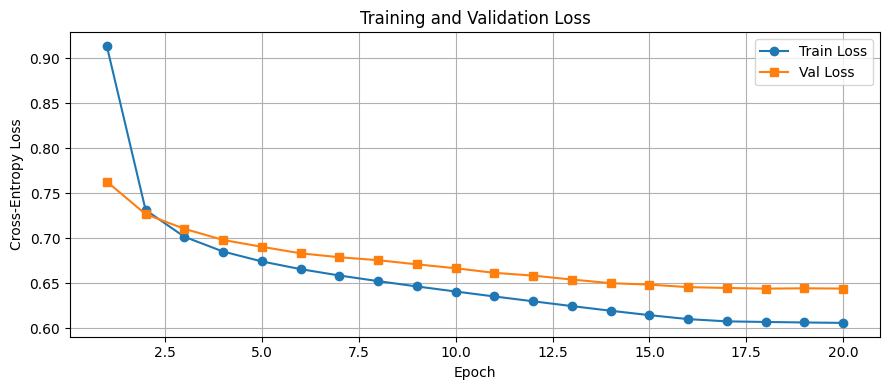

Final Train Loss: 0.6057 | Final Val Loss: 0.6438


In [33]:
# Plot and save training / validation loss curves
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, EPOCHS + 1), val_losses,   marker='s', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Final Train Loss: {train_losses[-1]:.4f} | Final Val Loss: {val_losses[-1]:.4f}')

In [34]:
torch.save({
    'model_state_dict': model.state_dict(),
    'char_to_idx': char_to_idx,
    'idx_to_char': idx_to_char,
    'vocab_size': vocab_size,
    'block_size': seq_length,
}, os.path.join(out_dir, 'tinygpt_checkpoint.pt'))

print('Saved to:', out_dir)
print('Files:', os.listdir(out_dir))

Saved to: /content/part1_output
Files: ['checkpoint_epoch13.pt', 'tinygpt_checkpoint.pt', 'checkpoint_epoch11.pt', 'checkpoint_epoch06.pt', 'checkpoint_epoch10.pt', 'checkpoint_epoch05.pt', 'checkpoint_epoch17.pt', 'checkpoint_epoch18.pt', 'checkpoint_epoch01.pt', 'checkpoint_epoch08.pt', 'checkpoint_epoch02.pt', 'checkpoint_epoch14.pt', 'checkpoint_epoch12.pt', 'checkpoint_epoch03.pt', 'checkpoint_epoch16.pt', 'checkpoint_epoch07.pt', 'checkpoint_epoch19.pt', 'model.pth', 'checkpoint_epoch20.pt', 'checkpoint_epoch04.pt', 'checkpoint_epoch15.pt', 'checkpoint_epoch09.pt']


In [35]:
# Text generation
def generate_text(prompt, max_new_tokens=200, temperature=1.0):
    model.eval()
    encoded = encode(prompt)
    context = torch.tensor(encoded, dtype=torch.long, device=device).unsqueeze(0)
    out = model.generate(context, max_new_tokens=max_new_tokens, temperature=temperature)
    return decode(out[0].tolist())


prompt = 'Once upon a time'

print('--- Greedy Decoding (temperature=0) ---')
print(generate_text(prompt, max_new_tokens=400, temperature=0))

print('\n--- Temperature Sampling (T=0.8) ---')
print(generate_text(prompt, max_new_tokens=400, temperature=0.8))

print('\n--- Temperature Sampling (T=1.2) ---')
print(generate_text(prompt, max_new_tokens=400, temperature=1.2))

--- Greedy Decoding (temperature=0) ---
Once upon a time, there was a little girl named Lily. She loved to play with her toys and run around outside. One day, she found a big box in her room. It was full of toys and clothes. She wanted to play with it, but she couldn't reach it. She tried to pull it out, but it was too hard. She tried to pull it out, but it was too hard. 

Lily saw a big box of crayons on the floor. She wanted to pull the crayons out o

--- Temperature Sampling (T=0.8) ---
Once upon a time, there was a little girl named Lily. She loved to play with her dolls and run around outside. One day, she saw her friend Jack walking near the park. Jack told her about his doll. Jack was very sad, and Lily felt bad. They both wished they had another ball to play with. But then, Jack accidentally hit a big rock on the fence. Lily was sad and didn't know what to do.

Timmy's mom told him they cou

--- Temperature Sampling (T=1.2) ---
Once upon a time, there was a group of ductors. Th

## 1.4 Sequence Model Failure Analysis

In [38]:
failure_samples = []
prompts = ['Once upon a time', 'The little dog', 'One day a girl named']

for p in prompts:
    out = generate_text(p, max_new_tokens=400, temperature=1.0)
    failure_samples.append(out)
    print(f'Prompt: "{p}"')
    print(out)
    print('-' * 70)

Prompt: "Once upon a time"
Once upon a time there was a tough little leather bear. He liked to use a creek the water to carry through his bright blue and red shorts that were bigger than anything. 

One day, the little boy went outside to play. He put his skies together and looked up at the sky. Then, he saw something hidden in the water. It was a big, fat crab. He burned the crab's eye, and it began to hurt. The crabs ran to him, but Timm
----------------------------------------------------------------------
Prompt: "The little dog"
The little dog loved to crawl quickly. Every day, he would run around the park, laughing and shorolling his legs.

One day, the little dog saw the horse. The dog was big and barked. It wanted to play with the horse. So, the little dog ran after the horse. The boy was happy because tomorrow he would bring something special.
Once upon a time, there was a young girl named Lily. She loved playing with her mommy and
---------------------------------------------

In [36]:
failure_cases = [
    {
        'snippet': 'She tried to pull it out, but it was too hard. She tried to pull it out, but it was too hard.',
        'type': 'Repetition',
        'observation': 'Greedy decoding (temperature=0) collapses into a repetition loop. Once the model finds a high-probability continuation, it keeps selecting the same tokens with no mechanism to penalise repeated phrases, causing the same sentence to be generated verbatim multiple times.',
    },
    {
        'snippet': 'Jack told her about his doll. Jack was very sad, and Lily felt bad. They both wished they had another ball to play with. But then, Jack accidentally hit a big rock on the fence. Lily was sad and didn\'t know what to do. Timmy\'s mom told him they cou',
        'type': 'Loss of Coherence',
        'observation': 'The narrative loses track of its own context mid-story, shifting from dolls to a rock on a fence, then abruptly introducing a completely new character Timmy with no connection to the preceding events. The model generates locally plausible sentences but fails to maintain global narrative consistency.',
    },
    {
        'snippet': 'There was a group of ductors. They were very kind and brave boys and always had wife. One day, the movie asked him to immediately Bob, who was super curious. Bob wugged his toys and books.',
        'type': 'Hallucination / Nonsense',
        'observation': 'High temperature sampling causes the model to select low-probability tokens, producing non-existent words like "ductors" and "wugged", and semantically nonsensical phrases like "the movie asked him" and "always had wife". The model loses all narrative coherence and generates text that is syntactically structured but meaningless.',
    },
]

for i, fc in enumerate(failure_cases, 1):
    print(f'Failure Case {i}')
    print(f'  Type       : {fc["type"]}')
    print(f'  Snippet    : ...{fc["snippet"]}...')
    print(f'  Observation: {fc["observation"]}')
    print()

Failure Case 1
  Type       : Repetition
  Snippet    : ...She tried to pull it out, but it was too hard. She tried to pull it out, but it was too hard....
  Observation: Greedy decoding (temperature=0) collapses into a repetition loop. Once the model finds a high-probability continuation, it keeps selecting the same tokens with no mechanism to penalise repeated phrases, causing the same sentence to be generated verbatim multiple times.

Failure Case 2
  Type       : Loss of Coherence
  Snippet    : ...Jack told her about his doll. Jack was very sad, and Lily felt bad. They both wished they had another ball to play with. But then, Jack accidentally hit a big rock on the fence. Lily was sad and didn't know what to do. Timmy's mom told him they cou...
  Observation: The narrative loses track of its own context mid-story, shifting from dolls to a rock on a fence, then abruptly introducing a completely new character Timmy with no connection to the preceding events. The model generates loca

In [42]:
# Copy model files
shutil.copy('/content/part1_output/model.pth', '/app/model.pth')
shutil.copy('/content/part1_output/tinygpt_checkpoint.pt', '/app/tinygpt_checkpoint.pt')
shutil.copy('/content/loss_curves.png', '/app/loss_curves.png')

print('Done! Files in your Desktop folder:')
print(os.listdir('/app'))

Done! Files in your Desktop folder:
['.ipynb_checkpoints', 'Data266_Lab1_Part1.ipynb', 'loss_curves.png', 'model.pth', 'tinygpt_checkpoint.pt']
